In [1]:
# Import libraries
from src import load_material as tools
from src import lambda_interpolate as interp
import numpy as np
import matplotlib.pyplot as plt
import miepython as mie
import pandas as pd

In [2]:
# Load material from CSV and preallocate arrays
material = "materials/silicon.csv"
ref_lam = []
ref_n = []
ref_k = []

# Extract data from CSV file and double check the lengths of the arrays
df = pd.read_csv(material, delimiter = ",", header = 0, names = ["wl", "n", "k"], dtype = float)
ref_lam = df["wl"]
ref_n = df["n"]
ref_k = df["k"]

wvl_range = np.linspace(1.91E-1, max(ref_lam), 1000)  # Wavelength range for interpolation in microns, interpolation at 191 nm to match William's data starting at 200 nm

# Double check sizes
print(len(ref_lam), len(ref_n), len(ref_k))

46 46 46


In [3]:
# Interpolate n, k
n, k = interp.wvl_interpolation(wvl_range, ref_lam, ref_n, ref_k)

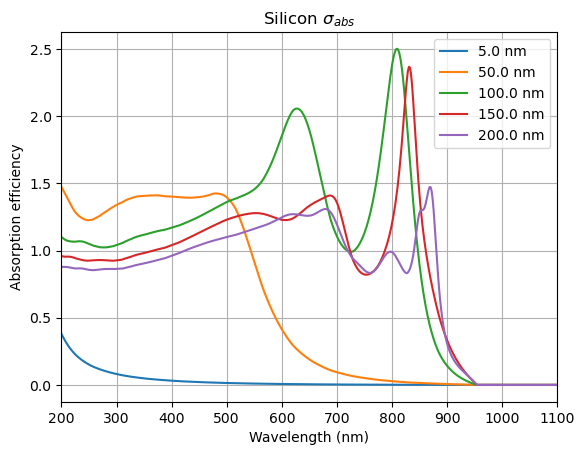

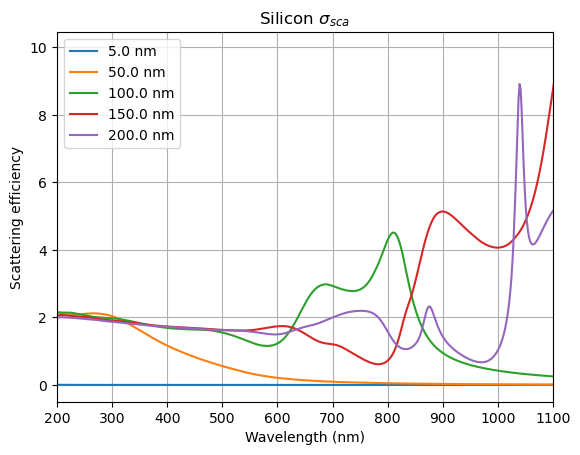

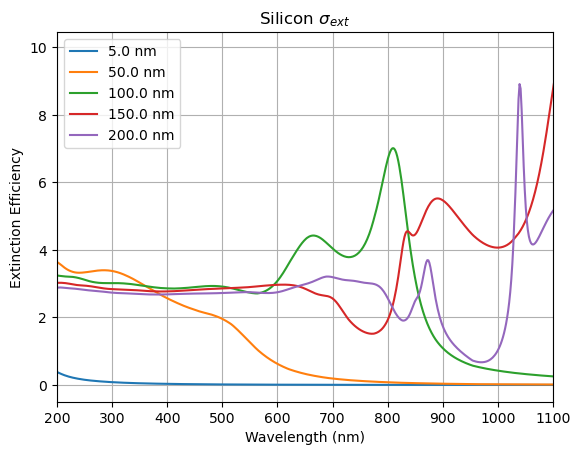

In [4]:
# TEST cross section for different radii in Silicon -- William's collaboration
r_range = [0.005, 0.05, 0.1, 0.15,  0.2]  # in microns
m = n - 1.0j * k

for i in r_range:
    x = 2 * np.pi * i / wvl_range
    cross_section_area = np.pi * i**2
    mu = 4 * np.pi * k / wvl_range  # nm
    qext, qsca, qback, g = mie.efficiencies_mx(m, x)
    qabs = qext - qsca

    plt.figure(1)
    plt.plot(wvl_range*1000, qabs, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.xlim(200, 1100)
    plt.ylabel("Absorption efficiency")
    plt.title(r'Silicon $\sigma_{abs}$ ')
    plt.legend()
    plt.grid()

    plt.figure(2)
    plt.plot(wvl_range*1000, qsca, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.xlim(200, 1100)
    plt.ylabel("Scattering efficiency")
    plt.title(r'Silicon $\sigma_{sca}$ ')
    plt.legend()
    plt.grid()

    plt.figure(3)
    plt.plot(wvl_range*1000, qext, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.xlim(200, 1100)
    plt.ylabel("Extinction Efficiency")
    plt.title(r'Silicon $\sigma_{ext}$ ')
    plt.legend()
    plt.grid()

plt.show()

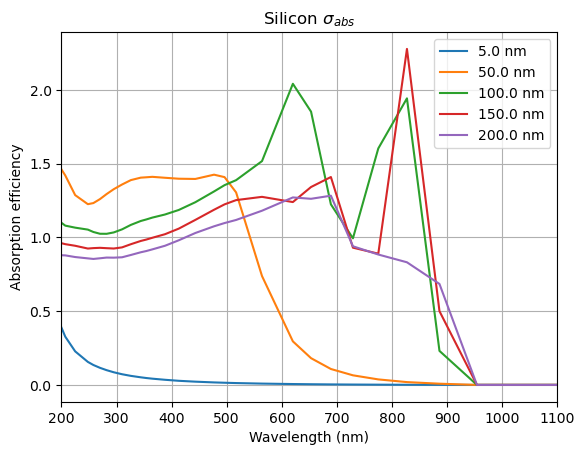

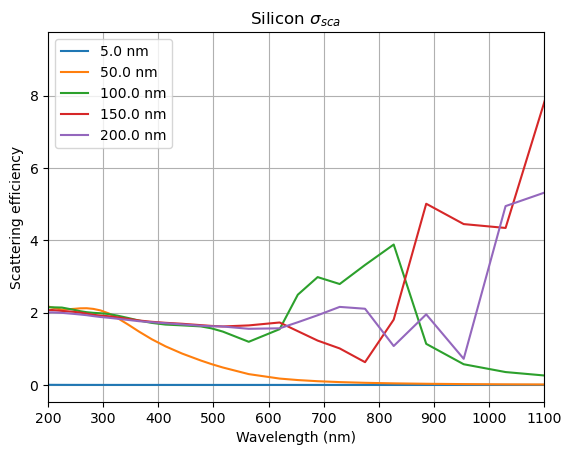

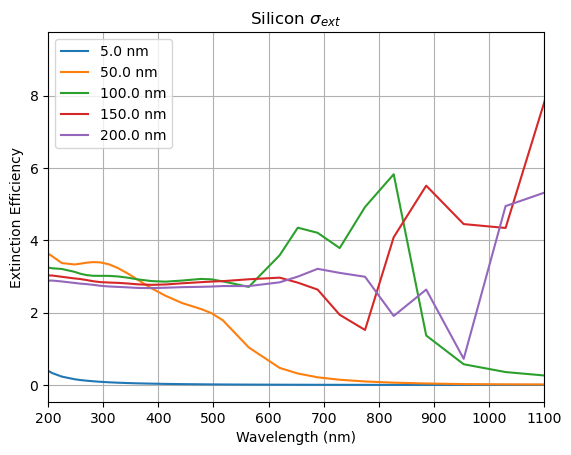

In [7]:
# TEST cross section for different radii in Silicon -- William's collaboration
r_range = [0.005, 0.05, 0.1, 0.15,  0.2]  # in microns
m = ref_n - 1.0j * ref_k
mu = 4 * np.pi * ref_k / ref_lam  # nm

for i in r_range:
    x = 2 * np.pi * i / ref_lam
    cross_section_area = np.pi * i**2
    qext, qsca, qback, g = mie.efficiencies_mx(m, x)
    qabs = qext - qsca

    plt.figure(1)
    plt.plot(ref_lam*1000, qabs, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.xlim(200, 1100)
    plt.ylabel("Absorption efficiency")
    plt.title(r'Silicon $\sigma_{abs}$ ')
    plt.legend()
    plt.grid()

    plt.figure(2)
    plt.plot(ref_lam*1000, qsca, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.xlim(200, 1100)
    plt.ylabel("Scattering efficiency")
    plt.title(r'Silicon $\sigma_{sca}$ ')
    plt.legend()
    plt.grid()

    plt.figure(3)
    plt.plot(ref_lam*1000, qext, label=f"{i*1000} nm")
    plt.xlabel("Wavelength (nm)")
    plt.xlim(200, 1100)
    plt.ylabel("Extinction Efficiency")
    plt.title(r'Silicon $\sigma_{ext}$ ')
    plt.legend()
    plt.grid()

plt.show()

In [ ]:
# generate CSV for different radii, validate with William's data. Dealt with it later exclusively in the check.ipynb notebook
r_range = np.arange(1, 250, 5)  # in microns
m = ref_n - 1.0j * ref_k
aDF = pd.DataFrame({"Wavelength / Radius (nm)": ref_lam * 1000})

# Preallocate lists
columns = []
radii_um = []

for i in r_range:
    radius_um = i * 0.001  # Convert radius from nm to microns
    x = 2 * np.pi * radius_um / ref_lam
    cross_section_area = np.pi * radius_um**2
    qext, qsca, qback, g = mie.efficiencies_mx(m, x)
    qabs = qext - qsca

    col_name = i
    aDF[col_name] = qabs
    columns.append(col_name)
    radii_um.append(radius_um)

# save data in separate CSV file in tests folder
aDF.to_csv("tests/test.csv", index=False)